In [9]:
import numpy as np

In [2]:
from data.loaders import MyoGymLoader, RecoFitLoader
from data.preprocessing import create_windows, setup_binary_classification, split_by_trainer

In [3]:
myogym_loader = MyoGymLoader("../../../data/datasets/MyoGym.mat")
myogym_data_df, myogym_mapping = myogym_loader.load_data()

In [4]:
x, y, meta = create_windows(myogym_data_df)

In [5]:
myogym_data_df.loc[meta[5000]["original_indices"]]

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,activity,trainer,time
263823,-0.761230,0.274414,0.779785,62.6875,1.7500,-4.8125,0,2,966.00
263824,-0.789063,0.263672,0.721191,61.0625,5.6875,-11.2500,0,2,966.02
263825,-0.839355,0.162598,0.716309,47.9375,7.3750,-10.3750,0,2,966.04
263827,-0.833496,0.081055,0.738281,47.5000,5.0625,-5.4375,0,2,966.06
263828,-0.808594,0.149414,0.719727,60.6875,1.3750,2.5625,0,2,966.08
...,...,...,...,...,...,...,...,...,...
263947,-0.363281,0.344238,0.749512,-61.3125,-0.3125,-30.7500,0,2,967.90
263948,-0.422852,0.360840,0.775391,-52.3125,-3.6875,-18.2500,0,2,967.92
263949,-0.530762,0.399902,0.768066,-48.7500,-1.5000,-3.8750,0,2,967.94
263950,-0.442871,0.382324,0.743164,-46.1875,-1.6250,-2.5625,0,2,967.96


In [6]:
x_train, y_train, meta_train, x_val, y_val, meta_val, x_test, y_test, meta_test = split_by_trainer(x, y, meta)

In [7]:
from plotting import plot_window, plot_window_from_df

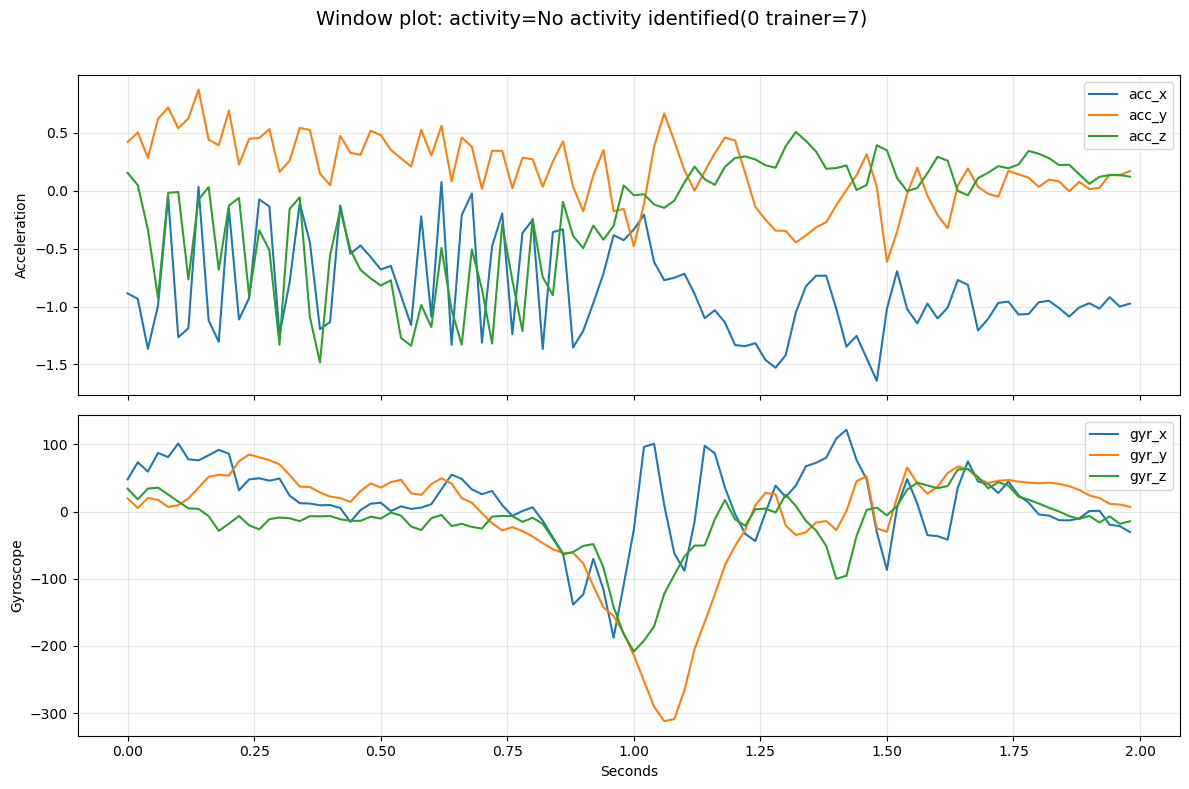

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: ylabel='Acceleration'>,
        <Axes: xlabel='Seconds', ylabel='Gyroscope'>], dtype=object))

In [8]:
plot_window(x_test[5000], y_test[5000], myogym_mapping, trainer=meta_test[5000]["trainer"])

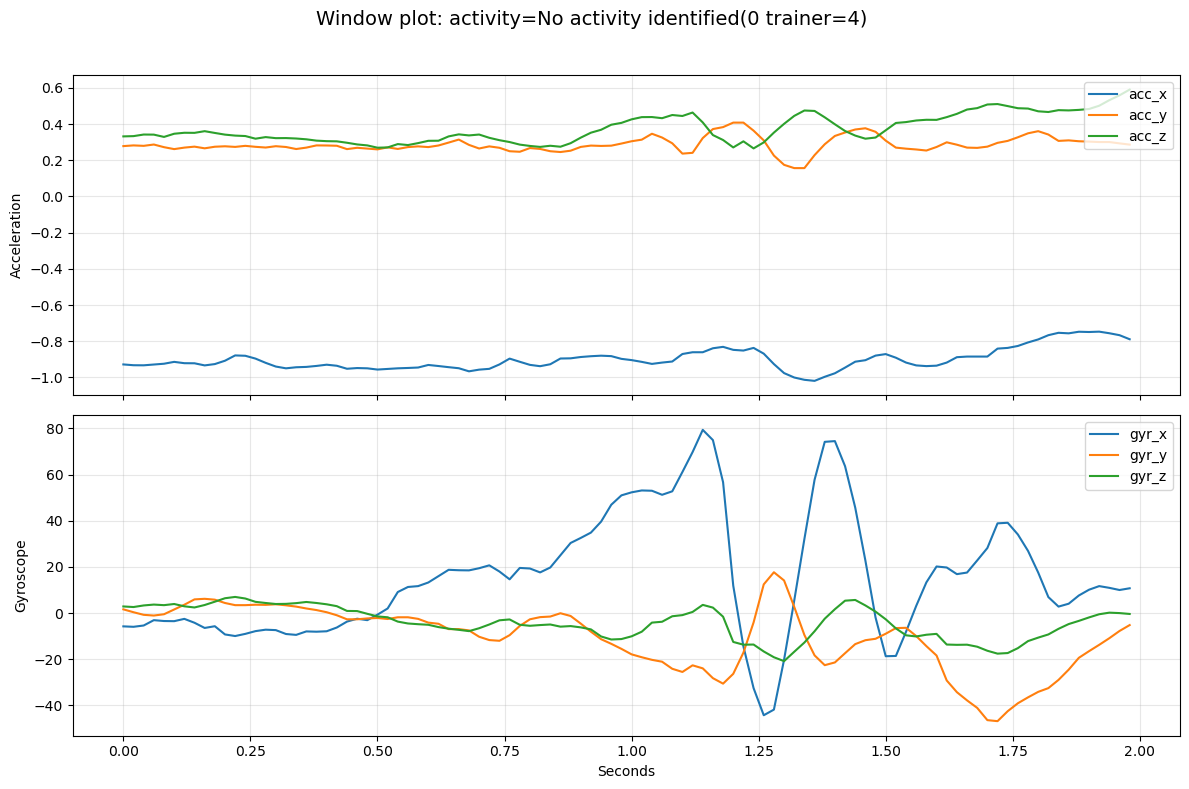

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: ylabel='Acceleration'>,
        <Axes: xlabel='Seconds', ylabel='Gyroscope'>], dtype=object))

In [9]:
plot_window_from_df(myogym_data_df.loc[meta_test[0]["original_indices"]], myogym_mapping)

In [10]:
y_train_binary = setup_binary_classification(y_train, myogym_mapping, myogym_loader.get_non_lifting_activities())
y_val_binary = setup_binary_classification(y_val, myogym_mapping, myogym_loader.get_non_lifting_activities())
y_test_binary = setup_binary_classification(y_test, myogym_mapping, myogym_loader.get_non_lifting_activities())

In [11]:
myogym_loader.get_non_lifting_activities()

{0: 'No activity identified'}

In [12]:
myogym_mapping[0] in myogym_loader.get_non_lifting_activities().values()

True

In [ ]:
print(f"Original: {y_train[4500]}, Binary: {y_train_binary[4500]}, Activity: {myogym_mapping[y_train[4500]]}")

Original: 27, Binary: 1, Activity: Front Dumbbell Raise


In [6]:
recofit_loader = RecoFitLoader("../../../data/datasets/RecoFit")
recofit_data_df, recofit_mapping = recofit_loader.load_data()

x_recofit, y_recofit, meta_recofit = create_windows(recofit_data_df)
x_train_rf, y_train_rf, meta_train_rf, x_val_rf, y_val_rf, meta_val_rf, x_test_rf, y_test_rf, meta_test_rf = split_by_trainer(x_recofit, y_recofit, meta_recofit)

y_train_rf_binary = setup_binary_classification(y_train_rf, recofit_mapping, recofit_loader.get_non_lifting_activities())



In [12]:
print(f"Original: {y_train_rf[4500]}, Binary: {y_train_rf_binary[4500]}, Activity: {recofit_mapping[y_train_rf[4500]]}")

Original: 42, Binary: 1, Activity: Rowing machine
